# Introduzione a PyTorch

PyTorch fornisce diversi moduli, di cui ``torch.nn`` è quello base per  la creazione dei modelli neurali, mentre i dati sono gestiti tramite ``torch.utils.data.DataSet`` che si occupa di caricare i dati dalle sorgenti e creare i tensori e ``torch.utils.data.DataLoader`` che si occupa di creare i batch e caricarli sul device selezionato per l'addestramento.
Esitono poi le librerie ``torchvision``, ``torchtext`` e ``torchaudio`` che forniscono data set specifici e funzioni di gestione per i tre domini di riferimento.

Utilizzeremo il nostro modulo ``torchnn`` con la semplice API per automatizzare la procedura di addestramento e valutazione del modello.

In [1]:
# Importiamo tutte le librerire necessarie
import torch
from torch import nn
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import v2
import os
import matplotlib.pyplot as plt
from torchsummary import summary
from torchnn import *

Il codice seguente serve a creare una semplice struttura di cartelle a partire da una root directory di vostra scelta, all'interno della quale vengono create due crtelle ``data`` per i data set e ``models`` per salvare i modelli.

In [2]:
# root dei percorsi -- da impostare a seconda delle proprie esigenze
root = "C:/Users/giova/Documents/GitHub/BigData2/Condiviso/Giovanni/Simulazione"
os.makedirs(root, exist_ok=True)

# percorso dei dati
data_path = os.path.join(root,'data')

# lo creiamo la prima volta
if not os.path.exists(data_path):
    os.mkdir(data_path)

# Analogamente per il percorso dei modelli
model_path = os.path.join(root,'models')

if not os.path.exists(model_path):
    os.mkdir(model_path)


In [3]:
# Acquisiamo il device su cui effettueremo il training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


Useremo il database ``FashionMNIST``per il nostro esempio: si tratta di 70000 immagini di dimensione 28x28, a livelli di grigio, che ritraggono capi di abbigliamento e sono associate a delle etichette testuali ch riportano il tipo di capo.

Abbiamo a che fare quindi con un problema di classificazione multiclasse di immagini che affronteremo con una rete neurale convoluizonale.

Il data set è suddiviso in un training set da 60000 immagini e un test set da 10000 immagini. Eseguiremo il download direttamente tramite ``torch`` che genererà un ``DataSet``.

In [4]:
# Definiamo un set di trasformazioni per implementare la data augmentation
transforms = v2.Compose([
    v2.RandomAffine(degrees=(-20, 20), translate=(0.15, 0.15)), # rotazione random di un angolo tra -20° e +20°
    v2.RandomHorizontalFlip(p=0.5),                             # flip orizzontale con probabilità del 50%
    v2.ToImage(),                                               # Composizione di trasformazioni
    v2.ToDtype(torch.float32, scale=True)                       # equivalente a ToTensor e raccomandata dalla documentaizone
])

tensors = v2.Compose([
    v2.ToImage(),                                               # Composizione di trasformazioni
    v2.ToDtype(torch.float32, scale=True)])                     # equivalente a ToTensor e raccomandata dalla documentaizone

In [ ]:
# flag per forzare il download del data set solo la prima volta
download = not os.path.exists(os.path.join(data_path,'FashionMNIST'))

# Download del training set da un open data set.
training_data = datasets.FashionMNIST(
    root=data_path,
    train=True,         # esegue il download dalla cartella/archivio dei dati di train del data set originale
    download=download,
    transform=transforms,
)

# Download del training set da un open test set.
test = datasets.FashionMNIST(
    root=data_path,
    train=False,
    download=download,
    transform=tensors
)

# eseguiamo lo split 90% - 10% dei dati di train per creare il validation set
test_size = int(0.9 * len(test))
val_size = int(0.1 * len(test))

# spostiamo i dati sulla GPU prima dello split così gli indici dei due split fanno riferimento già a tensori sul device
training_data.data.to(device)
test.data.to(device)

test_data, val_data = random_split(test, [test_size, val_size])

print(f"Campioni nel training set: {len(training_data)}\
        \nCampioni nel validation set: {len(val_data)}\
        \nCampioni nel test set: {len(test_data)}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 38.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 875kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 11.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.8MB/s]


Campioni nel training set: 60000        
Campioni nel validation set: 1000        
Campioni nel test set: 9000


In [ ]:
###################################################
#AGGIUNTA
###################################################

import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, HalvingGridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC

print("Estrazione dati per Scikit-Learn in corso...")

# FashionMNIST ha immagini 28x28 in scala di grigi. 
# Estraiamo i tensori grezzi, li appiattiamo a 784 features e li normalizziamo tra 0 e 1.
X_train_ml = training_data.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_train_ml = training_data.targets.numpy()

X_test_ml = test.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_test_ml = test.targets.numpy()

print(f"Dimensioni X_train_ml: {X_train_ml.shape}")
print(f"Dimensioni X_test_ml: {X_test_ml.shape}")

Estrazione dati per Scikit-Learn in corso...
Dimensioni X_train_ml: (60000, 784)
Dimensioni X_test_ml: (10000, 784)


In [ ]:
###################################################
#AGGIUNTA
###################################################

print("--- Avvio Gradient Boosting (FashionMNIST) ---")

# Griglia snellita per un'esecuzione locale rapida
param_grid = {
    'learning_rate': [0.1, 0.2], 
    'max_iter': [50, 100], 
    'min_samples_leaf': [20, 50] 
}

clf = HistGradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    clf, 
    param_grid, 
    cv=3, 
    n_jobs=-1, 
    verbose=3
)

# Essendo "solo" 784 features, possiamo osare usando 5000 campioni invece di 1000,
# oppure scommentare la seconda riga per usare tutto il dataset se il tuo PC regge bene.
grid_search.fit(X_train_ml[:5000], y_train_ml[:5000]) 
# grid_search.fit(X_train_ml, y_train_ml)

best_gb = grid_search.best_estimator_
print(f"\nMigliori Parametri GB trovati: {grid_search.best_params_}")

# Calcolo accuratezza
acc_train_gb = accuracy_score(y_train_ml, best_gb.predict(X_train_ml))
acc_test_gb = accuracy_score(y_test_ml, best_gb.predict(X_test_ml))

print(f"GB - Accuracy Addestramento: {acc_train_gb:.4f}")
print(f"GB - Accuracy Predizione (Test): {acc_test_gb:.4f}")

--- Avvio Gradient Boosting (FashionMNIST) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Migliori Parametri GB trovati: {'learning_rate': 0.1, 'max_iter': 100, 'min_samples_leaf': 20}
GB - Accuracy Addestramento: 0.8741
GB - Accuracy Predizione (Test): 0.8532


### Tensori

Nel codice precedente abbiamo visto che la trasformazione usata nella creazione dei data set è quella tipica, ovvero la chiamata di ``torchvision.ToTensor()`` che converte un'immagine di dimensioni HxWxC in un tensore di dimensioni CxHxW. Le trasformazioni possono essere anche definite dall'utente attraverso funzioni lambda.

I tensori in Pytorch sono implementati in maniera molto simile agli array in ``numpy``: essi hanno diversi tipi dei dati, infatti la classe base ``torch.Tensor`` è il default che ha un ``dtype=torch.float32`` ed è un alias per ``torch.FloatTensor``.
Pytorch usa i tensori per implementare tutta l'algebra lineare, le operazioni di campionamento, e quelle che guidano la propagazione dei gradienti durante l'addestramento.

I tensori possono essere creati da specifiche operazioni che danno come risultato un tensore, come ``torch.randint()`` che vedremo tra poco e che genera un tensore di numeri interi casuali di data dimensione, oppure esplicitamente con ``torch.tensor()`` che crea un tensore da una struttura di tipo array.

### Dataset
Un ``Dataset`` è in genere implementato come una ``map`` Python, quindi con accesso a indice, ma può essere anche creato come sottoclasse di ``IterableDataset`` come un iteratore.

Diamo un'occhiata al nostro data set, ricordandoci che è implementato con accesso ad indice.

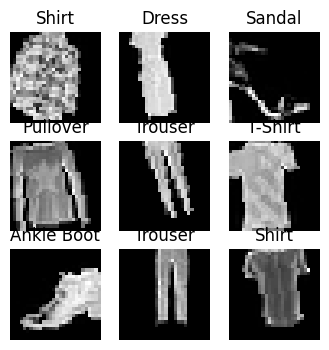

In [17]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(4, 4))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    # Genero un tensore casuale composto da un solo elemento nel range della lunghezza del data set
    # e lo converto in numero usando il metodo Tensor.item()
    sample_idx = int(torch.randint(len(training_data), size=(1,)).item())
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [18]:
# Creiamo i data loaders che saranno gli iterabili che generano i batch di
# addestramento e/o test
train_dataloader, val_dataloader, test_dataloader = make_dataloaders(training_data,
                                                                     val_data,
                                                                     test_data)

Shape e tipo dei campioni: torch.Size([64, 1, 28, 28]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [19]:
#  Creiamo il modello
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.deep_conv_stack = nn.Sequential(
            nn.Conv2d(1, 64, 3),        # Shape: (N, 1, 28, 28)   --> (N, 64, 26, 26) a causa del kernel 3x3
            nn.ReLU(),
            nn.Conv2d(64, 128, 3),      # Shape: (N, 64, 26, 26)  --> (N, 128, 24, 24)
            nn.ReLU(),
            nn.Conv2d(128, 256, 3),     # Shape: (N, 128, 24, 24) --> (N, 256, 22, 22)
            nn.ReLU(),
            nn.Conv2d(256, 64, 3),      # Shape: (N, 256, 22, 22) --> (N, 64, 20, 20)
            nn.ReLU(),
            nn.AvgPool2d(2),            # Shape: (N, 64, 20, 20)  --> (N, 64, 10, 10) a causa della divisione per due
            nn.Conv2d(64, 32, 3),       # Shape: (N, 64, 10, 10)  --> (N, 32, 8, 8)
            nn.ReLU(),
            nn.AvgPool2d(2),            # Shape: (N, 32, 8, 8)    --> (N, 32, 4, 4)
            nn.Flatten(1,-1),           # Shape: (N, 32, 4, 4)    --> (N, 512) il flatten moltiplica tutte le dimensioni tra loro
            nn.Linear(512, 10)          # Shape: (N, 512)         --> (N, 10) strato denso di calcolo dei logits
        )

    def forward(self, x):
        # Calcolo della rete in avanti
        logits = self.deep_conv_stack(x)                # parte profonda della rete che estrae i logits
        pred_probab = nn.LogSoftmax(dim=1)(logits)      # uscita esplicita con log-softmax per la predizione delle etichette
        return pred_probab

# Il metodo to() sposta il modello sul device selezionato
model = NeuralNetwork().to(device)

# Riportiamo il sommario del modello con torchinfo.summary()
summary(model, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
              ReLU-2           [-1, 64, 26, 26]               0
            Conv2d-3          [-1, 128, 24, 24]          73,856
              ReLU-4          [-1, 128, 24, 24]               0
            Conv2d-5          [-1, 256, 22, 22]         295,168
              ReLU-6          [-1, 256, 22, 22]               0
            Conv2d-7           [-1, 64, 20, 20]         147,520
              ReLU-8           [-1, 64, 20, 20]               0
         AvgPool2d-9           [-1, 64, 10, 10]               0
           Conv2d-10             [-1, 32, 8, 8]          18,464
             ReLU-11             [-1, 32, 8, 8]               0
        AvgPool2d-12             [-1, 32, 4, 4]               0
          Flatten-13                  [-1, 512]               0
           Linear-14                   

In [20]:
loss_fn = nn.NLLLoss()               # Negative log-likelihood

optimizer = torch.optim.SGD(
                            model.parameters(),
                            lr=config['learning_rate'],
                            momentum=config['momentum'],
                            nesterov=config['nesterov']
                            )

In [21]:
# Creiamo la callback di early stopping con i oarametri di deafault della configurazione da passare al nostro metodo di addestramento
early_stopping = EarlyStopping()

# Routine di addestramento
train_loss, validation_loss, test_loss, accuracy, metrics = train_test(model,
                                                              optimizer,
                                                              device,
                                                              train_dataloader,
                                                              test_dataloader,
                                                              train_loss_fn=loss_fn,
                                                              test_loss_fn=loss_fn,
                                                              early_stopping=early_stopping,
                                                              val_dataloader=val_dataloader)

Epoch    1: 100%|██████████| 938/938 [00:23<00:00, 39.87it/s]


Train loss: 2.0371
Validation loss: 1.0887
Test loss: 1.0856 Accuracy:   0.62
Metrics:
precision_score:   0.62  recall_score:   0.62  f1_score:   0.58  


Epoch    2: 100%|██████████| 938/938 [00:22<00:00, 42.51it/s]


Train loss: 1.0532
Validation loss: 0.8041
Test loss: 0.7950 Accuracy:   0.71
Metrics:
precision_score:   0.70  recall_score:   0.71  f1_score:   0.69  


Epoch    3: 100%|██████████| 938/938 [00:22<00:00, 42.27it/s]


...

Train loss: 0.6092
Validation loss: 0.5187
Test loss: 0.5309 Accuracy:   0.81
Metrics:
precision_score:   0.80  recall_score:   0.81  f1_score:   0.80  


Epoch   19: 100%|██████████| 938/938 [00:23<00:00, 40.38it/s]


Train loss: 0.6090
Validation loss: 0.5303
Test loss: 0.5430 Accuracy:   0.80
Metrics:
precision_score:   0.81  recall_score:   0.80  f1_score:   0.80  


Epoch   20: 100%|██████████| 938/938 [00:28<00:00, 32.90it/s]


Train loss: 0.6015
Validation loss: 0.5210
Test loss: 0.5327 Accuracy:   0.80
Metrics:
precision_score:   0.81  recall_score:   0.80  f1_score:   0.80  


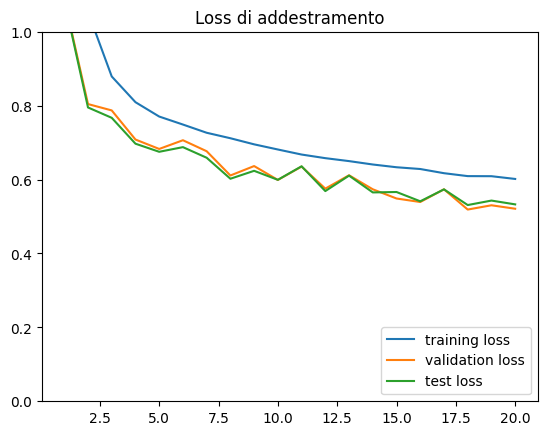

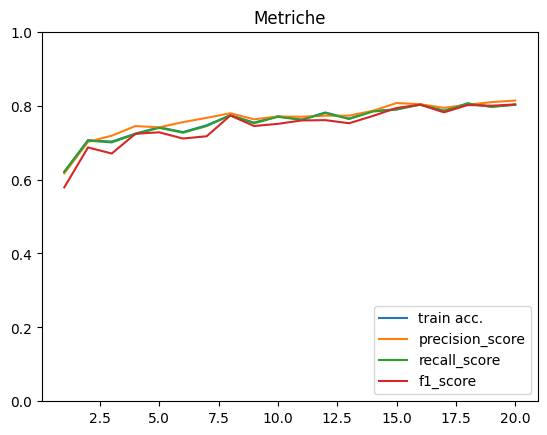

In [22]:
displayLosses(train_loss, test_loss, validation_loss)

displayMetrics(accuracy, metrics)

## Salvataggio e caricamento del modello

Come già sappiamo, quando l'addestramento si interrompe a causa di un early stoppping ovvero perché è necessario frazionarlo per gestire le risorse limitate della GPU, ma anche semplicemente alla sua fine naturale il modello viene salvato per poterlo successivamente ricaricare a fini di fine tuning o di predizione. Si usa chiamare questa azione _model checkpoint_.

Anche questa operazione andrà codificata creando delle semplici API basate sulle primitive di ``Torch`` denominate ``torch.save()`` e ``torch.load()`` le quali salvano un qualunque ``dict`` in forma serializzata utilizzando il modulo nativo ``Python`` denominato ``pickle``.

Creeremo due semplici wrapper per le operazioni di salvataggio e caricamento del model checkpoint.

In [23]:
# utilizziamo le API per salvare e ricaricare il modello
save_model(model,
           optimizer,
           len(train_loss),
           train_loss,
           validation_loss,
           test_loss,
           accuracy,
           metrics,
           os.path.join(model_path,'first_nn_torch.pth'))

mod = NeuralNetwork()
opt = torch.optim.SGD(mod.parameters(),
                            lr=config['learning_rate'],
                            momentum=config['momentum'],
                            nesterov=config['nesterov']
                            )

(mod, opt, model_checkpoint) = load_model(os.path.join(model_path,'first_nn_torch.pth'),
                                          mod,
                                          opt,
                                          device=device)

In [24]:
# Vogliamo riaddestrare il modello dopo l'early stopping, per cui
# inseriamo uno scheduler che faccia decrescere il learning rate ad ogni epoca
# come ulteriore regolarizzazione
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)

# Usiamo lo scheduler al posto dell'ottimizzatore nell'addestramento
tr_loss, val_loss, t_loss, new_accuracy, new_metrics = train_test(mod,
                                                                  opt, 
                                                                  device, 
                                                                  train_dataloader, 
                                                                  test_dataloader,
                                                                  epochs=5,
                                                                  train_loss_fn=loss_fn,
                                                                  test_loss_fn=loss_fn,
                                                                  scheduler=scheduler, 
                                                                  val_dataloader=val_dataloader)

Epoch    1: 100%|██████████| 938/938 [00:24<00:00, 39.02it/s]


Train loss: 0.5988
Validation loss: 0.5291
Test loss: 0.5487 Accuracy:   0.80
Metrics:
precision_score:   0.80  recall_score:   0.80  f1_score:   0.79  


Epoch    2: 100%|██████████| 938/938 [00:27<00:00, 33.74it/s]


Train loss: 0.5869
Validation loss: 0.5147
Test loss: 0.5286 Accuracy:   0.81
Metrics:
precision_score:   0.80  recall_score:   0.81  f1_score:   0.80  


Epoch    3: 100%|██████████| 938/938 [00:24<00:00, 38.60it/s]


Train loss: 0.5817
Validation loss: 0.5179
Test loss: 0.5180 Accuracy:   0.81
Metrics:
precision_score:   0.80  recall_score:   0.81  f1_score:   0.79  


Epoch    4: 100%|██████████| 938/938 [00:29<00:00, 31.59it/s]


Train loss: 0.5745
Validation loss: 0.4988
Test loss: 0.5166 Accuracy:   0.81
Metrics:
precision_score:   0.81  recall_score:   0.81  f1_score:   0.81  


Epoch    5: 100%|██████████| 938/938 [00:24<00:00, 39.07it/s]


Train loss: 0.5706
Validation loss: 0.5019
Test loss: 0.5133 Accuracy:   0.81
Metrics:
precision_score:   0.81  recall_score:   0.81  f1_score:   0.81  


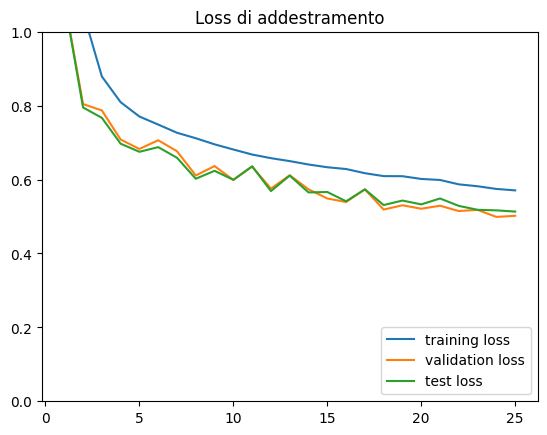

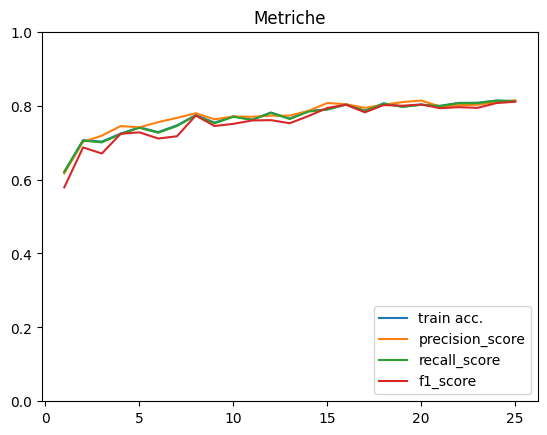

In [25]:
# concateniamo le liste delle loss e delle metriche relative ai due addestramenti e facciamo il plot
model_checkpoint['accuracy'].extend(new_accuracy)
model_checkpoint['training_loss'].extend(tr_loss)
model_checkpoint['validation_loss'].extend(val_loss)
model_checkpoint['test_loss'].extend(t_loss)

extended_metrics = {}
for label, metric in new_metrics.items():
    model_checkpoint[label].extend(metric)
    extended_metrics[label] = model_checkpoint[label]

displayLosses(model_checkpoint['training_loss'], model_checkpoint['test_loss'], model_checkpoint['validation_loss'])
displayMetrics(model_checkpoint['accuracy'], extended_metrics)



--- Estrazione probabilità dalla CNN per curve ROC ---

==== MATRICI DI CONFUSIONE ====
Matrice Confusione GB:
 [[804   2  18  39   5   1 122   0   9   0]
 [  1 953   3  32   7   0   3   0   1   0]
 [ 11   0 760   8 131   0  82   0   8   0]
 [ 28   2  19 875  33   1  40   0   2   0]
 [  0   0 114  35 789   0  59   0   3   0]
 [  0   0   1   0   0 926   1  43   4  25]
 [142   1 120  29 100   0 590   0  18   0]
 [  0   0   0   0   0  18   1 930   0  51]
 [  0   1   5   4   3   4  24   3 955   1]
 [  0   0   0   1   0   6   1  41   1 950]]

Matrice Confusione CNN:
 [[683   2  13  69  11   2 111   0   7   0]
 [  0 878   0  15   7   0   1   0   1   0]
 [  6   1 445   4 155   0 293   0   3   0]
 [ 27  20   4 740  47   0  54   0   0   2]
 [  1   2  23  44 655   1 159   0   2   0]
 [  0   0   0   0   0 775   1 101   3  21]
 [144   6  77  41 112   2 495   0  13   0]
 [  0   0   0   0   0   9   0 859   0  34]
 [  4   4  11   5  11   3  13   8 844   3]
 [  0   0   1   1   0   9   0  50   2 850]]


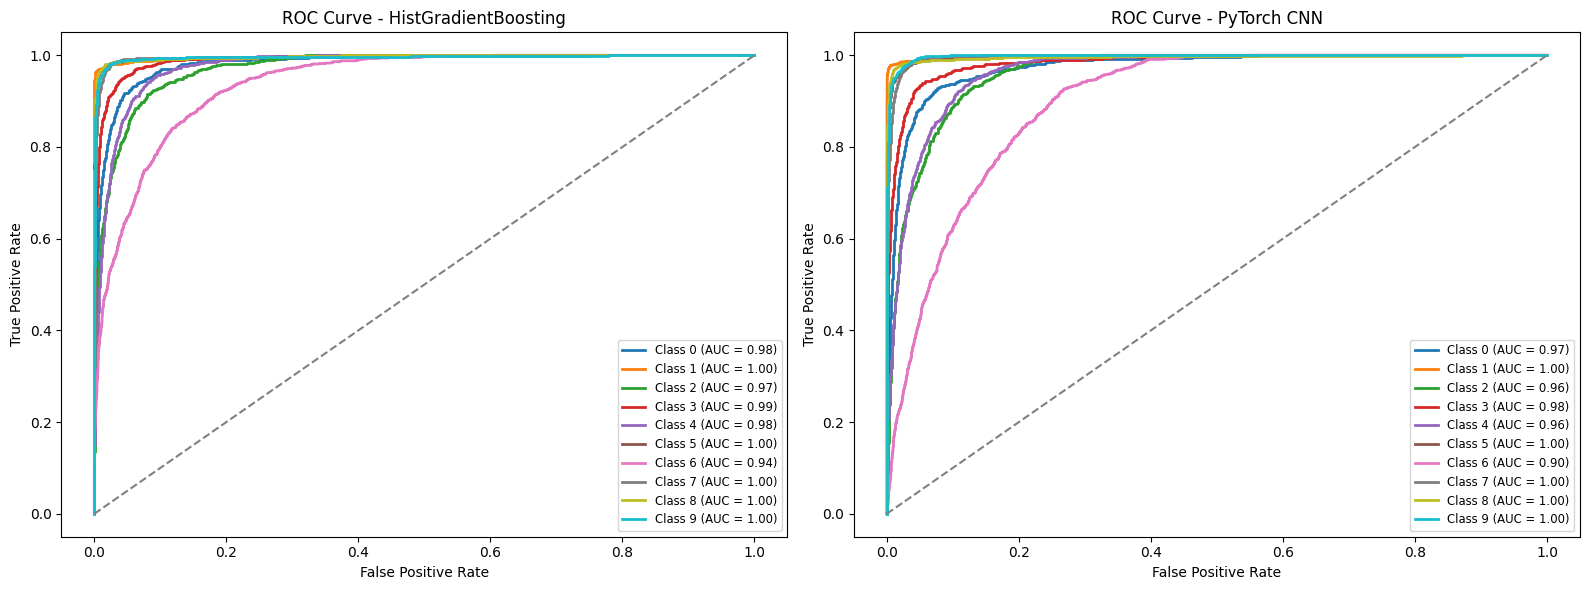

: 

In [ ]:
###################################################
#AGGIUNTA
###################################################

import matplotlib.pyplot as plt

print("--- Estrazione probabilità dalla CNN per curve ROC ---")

# 1. Otteniamo le probabilità dal modello CNN
modello = model # nome della variabile della CNN
modello.eval()

y_true_nn = []
y_pred_nn = []
y_prob_nn = []

# Usa test_dataloader (o test_loader)
with torch.no_grad():
    for X, y in test_dataloader: 
        X, y = X.to(device), y.to(device)
        logits = modello(X)
        probs = torch.softmax(logits, dim=1)
        
        y_true_nn.extend(y.cpu().numpy())
        y_pred_nn.extend(logits.argmax(1).cpu().numpy())
        y_prob_nn.extend(probs.cpu().numpy())
        
y_true_nn = np.array(y_true_nn)
y_prob_nn = np.array(y_prob_nn)

# 2. Matrici di Confusione
print("\n==== MATRICI DI CONFUSIONE ====")
print("Matrice Confusione GB:\n", confusion_matrix(y_test_ml, best_gb.predict(X_test_ml)))
print("\nMatrice Confusione CNN:\n", confusion_matrix(y_true_nn, y_pred_nn))

# 3. FIX: Binarizzazione etichette SEPARATA per evitare errori di dimensione
# Il GB usa y_test_ml (10000 campioni), la CNN usa y_true_nn (9000 campioni reali del dataloader)
y_test_bin_gb = label_binarize(y_test_ml, classes=range(10))
y_test_bin_nn = label_binarize(y_true_nn, classes=range(10))
y_prob_gb = best_gb.predict_proba(X_test_ml)

print("\n==== AUC PER SINGOLA CLASSE ====")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i in range(10):
    # Calcolo AUC usando i rispettivi array allineati
    auc_gb = roc_auc_score(y_test_bin_gb[:, i], y_prob_gb[:, i])
    auc_nn = roc_auc_score(y_test_bin_nn[:, i], y_prob_nn[:, i])
    print(f"Classe {i:2d} - AUC GB: {auc_gb:.4f} | AUC CNN: {auc_nn:.4f}")
    
    # Dati per Curve ROC
    fpr_gb, tpr_gb, _ = roc_curve(y_test_bin_gb[:, i], y_prob_gb[:, i])
    fpr_nn, tpr_nn, _ = roc_curve(y_test_bin_nn[:, i], y_prob_nn[:, i])
    
    # Plottiamo le curve
    ax1.plot(fpr_gb, tpr_gb, lw=2, label=f'Class {i} (AUC = {auc_gb:.2f})')
    ax2.plot(fpr_nn, tpr_nn, lw=2, label=f'Class {i} (AUC = {auc_nn:.2f})')

# Stile grafici
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_title('ROC Curve - HistGradientBoosting')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right", fontsize='small')

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_title('ROC Curve - PyTorch CNN')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc="lower right", fontsize='small')

plt.tight_layout()
plt.show()